# EDA: Phân tích dữ liệu mưa từ `Data/Data.csv`

Phân tích chi tiết dữ liệu mưa bao gồm: kiểm tra kích thước, cấu trúc, giá trị thiếu, outlier, phân phối dữ liệu, và biểu diễn trên bản đồ tương tác thế giới.

In [16]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
from folium.plugins import MarkerCluster, HeatMap
from tqdm import tqdm
import requests
import io
from pathlib import Path

# Configure plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Data path configuration
DATA_PATH = Path('Data') / 'Data.csv'
print('DATA_PATH:', DATA_PATH)
print('Exists:', DATA_PATH.exists())

DATA_PATH: Data\Data.csv
Exists: True


## 1. Kiểm tra nhanh kích thước và cấu trúc dữ liệu

In [17]:
# Basic information about the dataset
sample = pd.read_csv(DATA_PATH, nrows=0)
print('Columns:', sample.columns.tolist())
print('\nColumn data types:')
print(sample.dtypes)

# Count rows and columns
row_count = sum(1 for _ in open(DATA_PATH, encoding='utf-8')) - 1
col_count = len(sample.columns)
print(f'\nRows: {row_count:,}')
print(f'Columns: {col_count}')

Columns: ['time', 'nv', 'lat', 'lon', 'time_bnds', 'lat_bnds', 'lon_bnds', 'record_status', 'precipitation', 'num_obs_fraction', 'num_obs_rate', 'num_days', 'quality_flag', 'num_days_snow']

Column data types:
time                object
nv                  object
lat                 object
lon                 object
time_bnds           object
lat_bnds            object
lon_bnds            object
record_status       object
precipitation       object
num_obs_fraction    object
num_obs_rate        object
num_days            object
quality_flag        object
num_days_snow       object
dtype: object

Rows: 24,883,200
Columns: 14


### 1.1 Ý nghĩa các cột chính

- `time`: Ngày quan sát
- `lat`, `lon`: Vị trí tâm lưới (vĩ độ, kinh độ)
- `time_bnds`, `lat_bnds`, `lon_bnds`: Biên của khoảng thời gian và không gian
- `record_status`: Trạng thái bản ghi
- `precipitation`: Lượng mưa quan sát (mm)
- `num_obs_fraction`, `num_obs_rate`: Thông tin về tỷ lệ quan sát
- `num_days`: Số ngày dữ liệu có hiệu lực trong kỳ
- `quality_flag`: Chỉ số chất lượng dữ liệu
- `num_days_snow`: Số ngày có tuyết

In [18]:
# Descriptive statistics for numeric features
numeric_cols = [
    'lat', 'lon', 'precipitation', 'num_obs_fraction', 
    'num_obs_rate', 'num_days', 'quality_flag', 'num_days_snow'
]
sample = pd.read_csv(DATA_PATH, nrows=100000, usecols=numeric_cols)
print(sample.describe())

                 lat            lon  precipitation  num_obs_fraction  \
count  100000.000000  100000.000000   98920.000000      1.000000e+05   
mean      -14.470800      -0.112000       2.378687      5.440883e+05   
std        49.147799     103.887176       3.766903      7.915669e+05   
min       -89.500000    -179.500000       0.000000      0.000000e+00   
25%       -55.500000     -90.500000       0.000000      3.397750e+03   
50%       -20.500000      -0.500000       0.850000      2.572040e+05   
75%        20.500000      89.500000       3.030000      7.547560e+05   
max        89.500000     179.500000      34.910000      3.613954e+06   

        num_obs_rate       num_days   quality_flag  num_days_snow  
count  100000.000000  100000.000000  100000.000000  100000.000000  
mean   156330.606310      30.471940       0.026960      10.854720  
std    100228.359694       2.552508       0.273338      14.563612  
min       741.000000       0.000000       0.000000       0.000000  
25%     688

### 1.2 Xem trước dữ liệu

Kiểm tra một vài hàng đầu tiên để hiểu cấu trúc dữ liệu thực tế

In [19]:
# Load and display first rows
preview = pd.read_csv(DATA_PATH, nrows=10, parse_dates=['time'])
print(preview)

        time  nv   lat    lon   time_bnds  lat_bnds  lon_bnds  record_status  \
0 2005-01-01   0 -89.5 -179.5  2005-01-01     -90.0    -180.0              0   
1 2005-01-01   0 -89.5 -178.5  2005-01-01     -90.0    -179.0              0   
2 2005-01-01   0 -89.5 -177.5  2005-01-01     -90.0    -178.0              0   
3 2005-01-01   0 -89.5 -176.5  2005-01-01     -90.0    -177.0              0   
4 2005-01-01   0 -89.5 -175.5  2005-01-01     -90.0    -176.0              0   
5 2005-01-01   0 -89.5 -174.5  2005-01-01     -90.0    -175.0              0   
6 2005-01-01   0 -89.5 -173.5  2005-01-01     -90.0    -174.0              0   
7 2005-01-01   0 -89.5 -172.5  2005-01-01     -90.0    -173.0              0   
8 2005-01-01   0 -89.5 -171.5  2005-01-01     -90.0    -172.0              0   
9 2005-01-01   0 -89.5 -170.5  2005-01-01     -90.0    -171.0              0   

   precipitation  num_obs_fraction  num_obs_rate  num_days  quality_flag  \
0            NaN              15.0        1

## 2. Kiểm tra giá trị thiếu (Missing Values)

In [20]:
# Check missing values across all numeric columns
missing = pd.Series(0, index=numeric_cols)
for chunk in pd.read_csv(
    DATA_PATH, 
    usecols=numeric_cols, 
    chunksize=200_000, 
    dtype=str, 
    na_values=['', 'NA', 'nan']
):
    missing += chunk.isna().sum()

missing_pct = missing / row_count * 100
missing_df = pd.DataFrame({
    'missing_count': missing, 
    'missing_pct': missing_pct
}).sort_values('missing_count', ascending=False)
print(missing_df)

                  missing_count  missing_pct
precipitation            392864     1.578832
lat                           0     0.000000
lon                           0     0.000000
num_obs_fraction              0     0.000000
num_obs_rate                  0     0.000000
num_days                      0     0.000000
quality_flag                  0     0.000000
num_days_snow                 0     0.000000


Dữ liệu cho thấy chỉ cột `precipitation` có giá trị thiếu, điều này là hợp lý vì không phải lúc nào lượng mưa cũng được ghi lại ở tất cả các điểm lưới.

In [21]:
# Detailed analysis of precipitation
prec = pd.read_csv(DATA_PATH, usecols=['precipitation'], dtype={'precipitation': 'float32'})
prec_missing = prec['precipitation'].isna().sum()
prec_missing_pct = prec_missing / len(prec) * 100

print(f'Precipitation missing: {prec_missing:,} rows ({prec_missing_pct:.2f}%)')
print('\nDescriptive Statistics:')
print(prec['precipitation'].describe())
print('\nQuantiles:')
quantiles = prec['precipitation'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print(quantiles)

Precipitation missing: 392,864 rows (1.58%)

Descriptive Statistics:
count    2.449034e+07
mean     2.166213e+00
std      3.486833e+00
min      0.000000e+00
25%      1.000000e-02
50%      8.200000e-01
75%      2.830000e+00
max      7.019000e+01
Name: precipitation, dtype: float64

Quantiles:
0.01     0.000000
0.05     0.000000
0.25     0.010000
0.50     0.820000
0.75     2.830000
0.95     9.050000
0.99    16.889999
Name: precipitation, dtype: float32


## 3. Phân tích Outlier sử dụng IQR (Interquartile Range)

Phương pháp IQR giúp xác định các giá trị bất thường. Các giá trị cực lớn có thể là vùng mưa rất mạnh hoặc cần kiểm tra chất lượng dữ liệu.

In [22]:
# IQR method for outlier detection
q1 = prec['precipitation'].quantile(0.25)
q3 = prec['precipitation'].quantile(0.75)
iqr = q3 - q1
lower_bound = max(0.0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr

print(f'Q1: {q1:.4f}')
print(f'Q3: {q3:.4f}')
print(f'IQR: {iqr:.4f}')
print(f'Lower bound: {lower_bound:.4f}')
print(f'Upper bound: {upper_bound:.4f}')

# Identify outliers
outliers = prec[prec['precipitation'] > upper_bound]
print(f'\nOutlier count: {len(outliers):,}')
print(f'Outlier ratio: {len(outliers) / len(prec) * 100:.4f}%')
print('Top 10 precipitation values:', outliers['precipitation'].nlargest(10).values)

Q1: 0.0100
Q3: 2.8300
IQR: 2.8200
Lower bound: 0.0000
Upper bound: 7.0600

Outlier count: 1,892,590
Outlier ratio: 7.6059%
Top 10 precipitation values: [70.19 70.19 67.02 67.02 64.72 64.72 63.79 63.79 63.22 63.22]


## 4. Biểu đồ phân phối dữ liệu (Distribution Plots)

Phân tích phân phối của các biến số chính

In [23]:
# Load sample data for visualization (1% of total data)
CHUNK_SIZE = 200_000
SAMPLE_FRAC = 0.01

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    total_rows = sum(1 for _ in f) - 1
total_chunks = total_rows // CHUNK_SIZE + 1

sample_data = []
reader = pd.read_csv(
    DATA_PATH,
    usecols=numeric_cols,
    dtype={col: 'float32' for col in numeric_cols},
    chunksize=CHUNK_SIZE
)

for chunk in tqdm(reader, total=total_chunks, desc="Loading sample data"):
    chunk_sample = chunk.sample(frac=SAMPLE_FRAC)
    sample_data.append(chunk_sample)

df_sample = pd.concat(sample_data, ignore_index=True)
print(f'Sample data shape: {df_sample.shape}')

Loading sample data: 100%|██████████| 125/125 [00:20<00:00,  6.25it/s]

Sample data shape: (248832, 8)


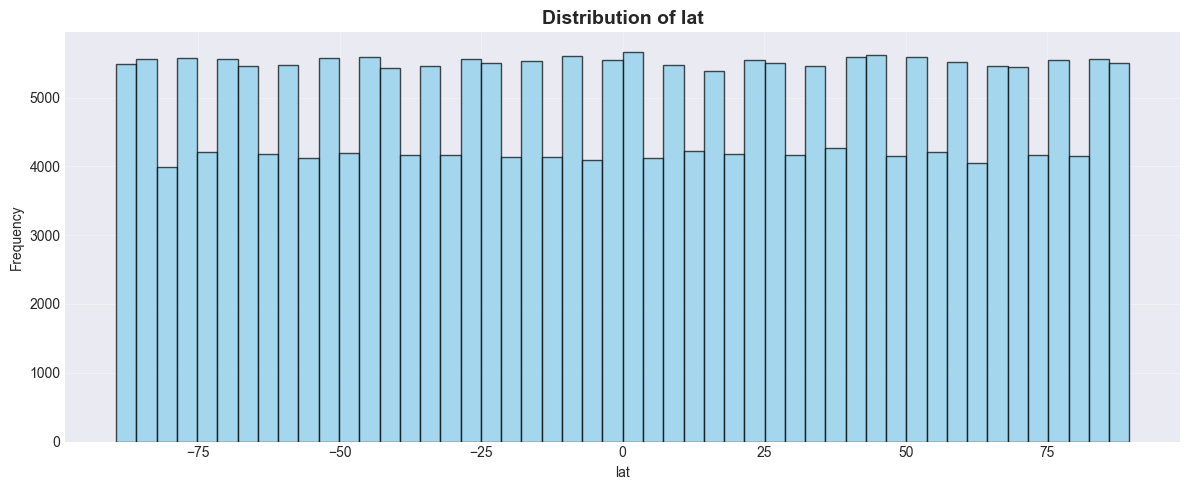

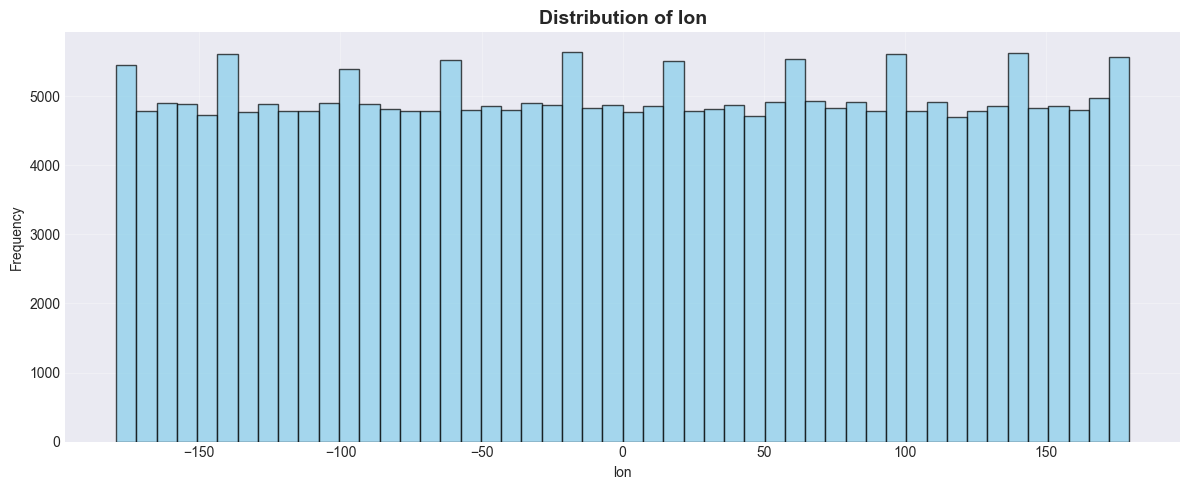

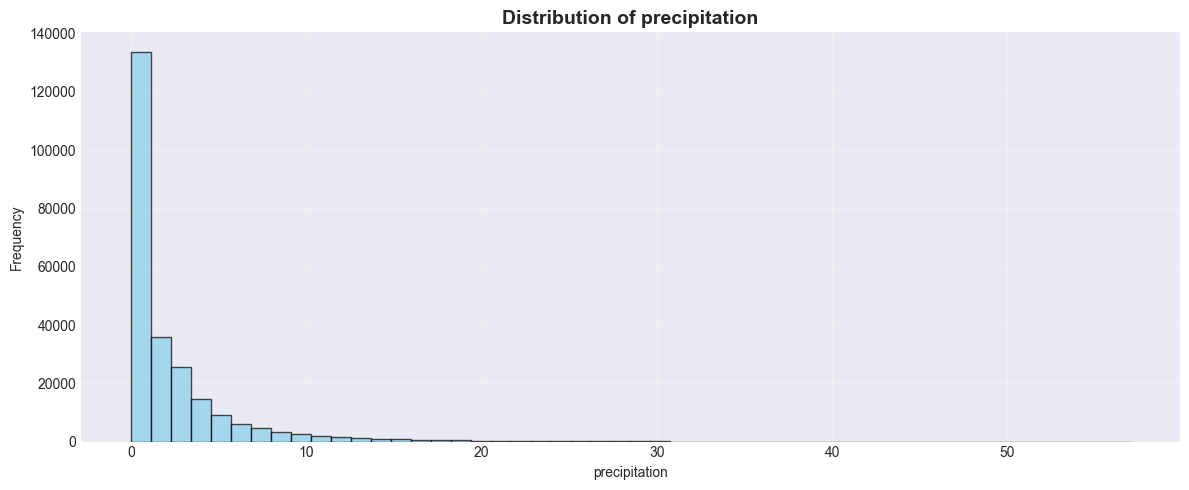

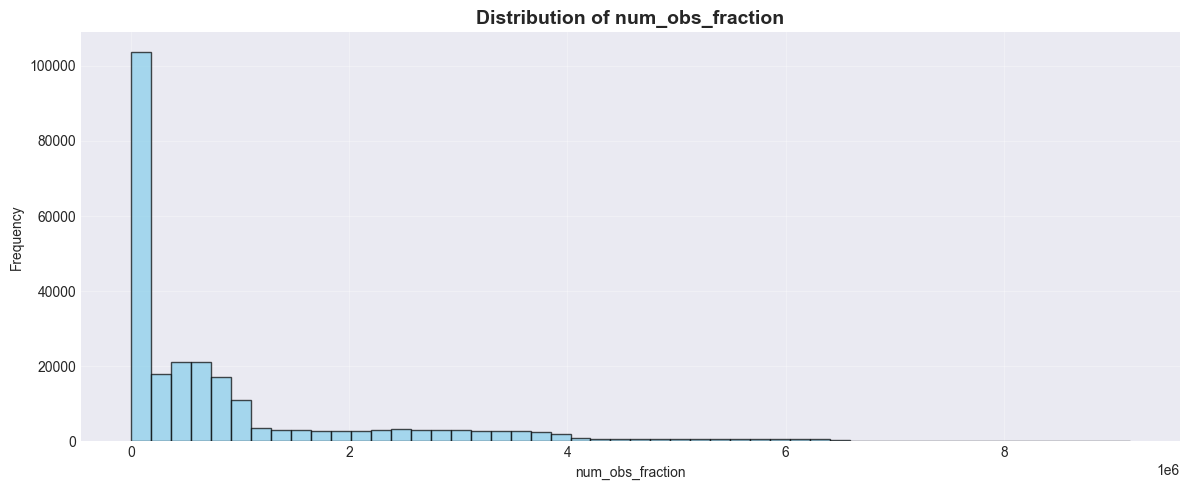

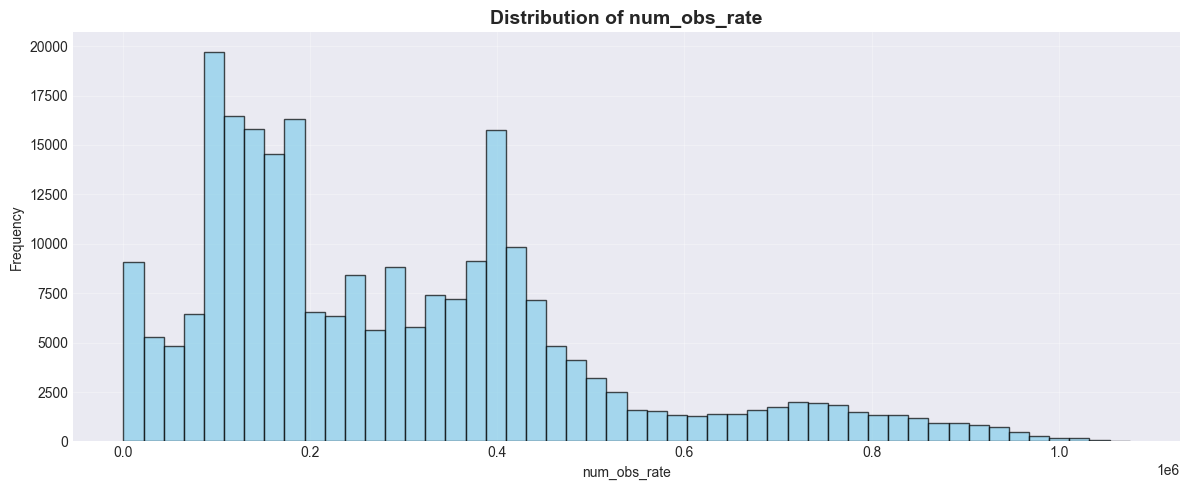

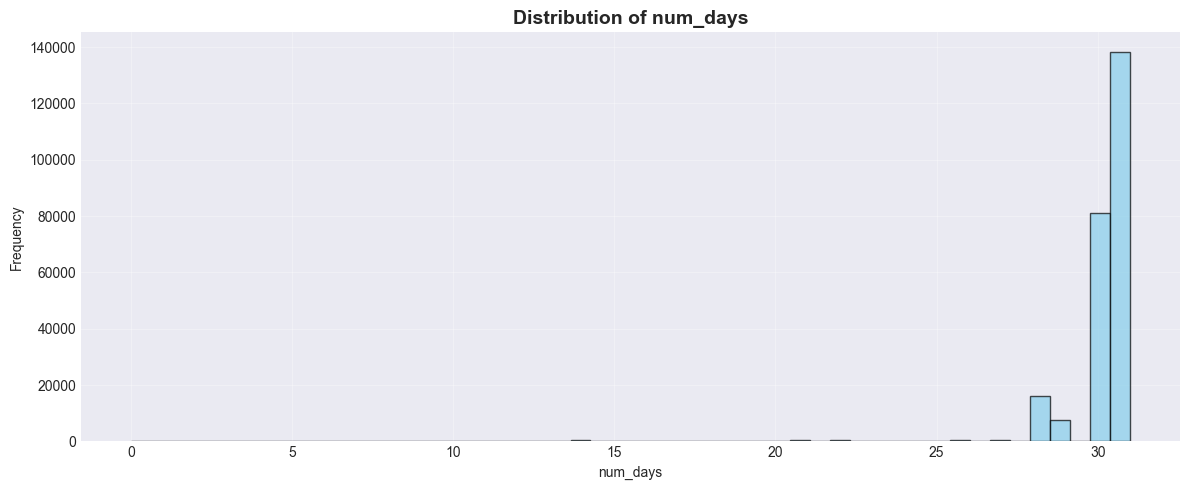

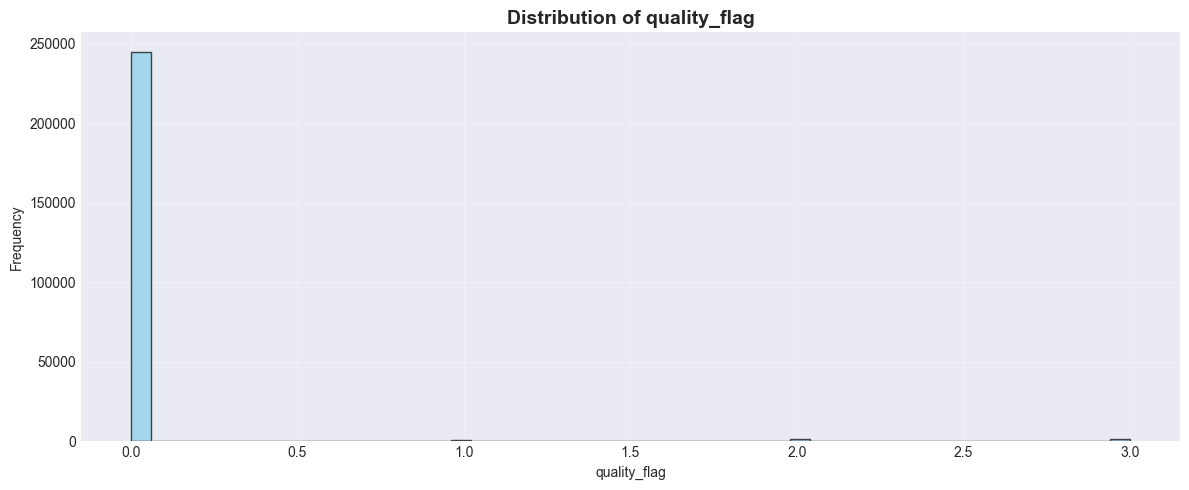

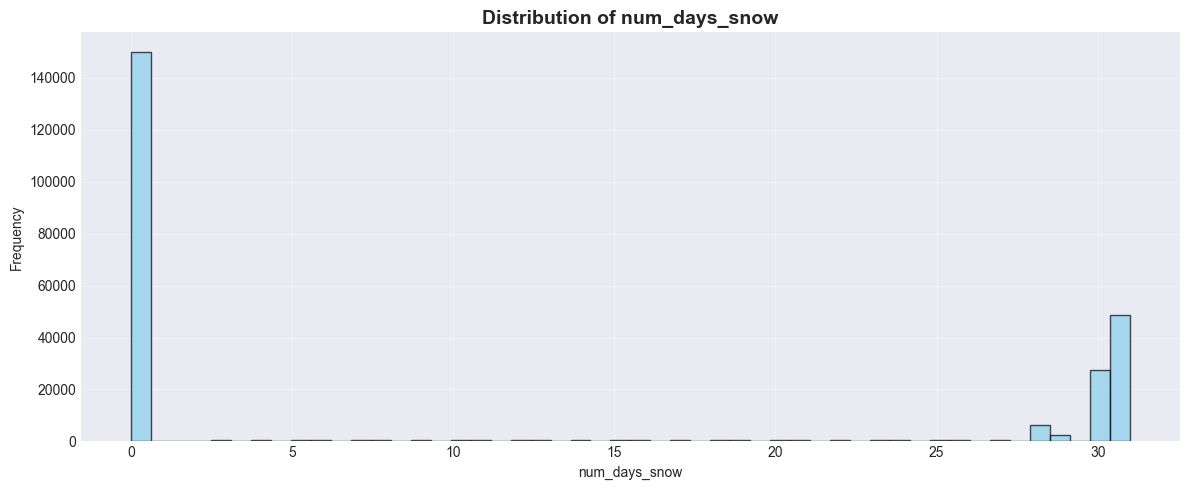

In [24]:
# Distribution plots for all numeric features (one plot per cell)
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(12, 5))
    data = df_sample[col].dropna()
    ax.hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontweight='bold', fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 4.1 Biểu đồ Precipitation với log scale

Log scale giúp làm rõ hơn phân phối của các giá trị nhỏ hơn

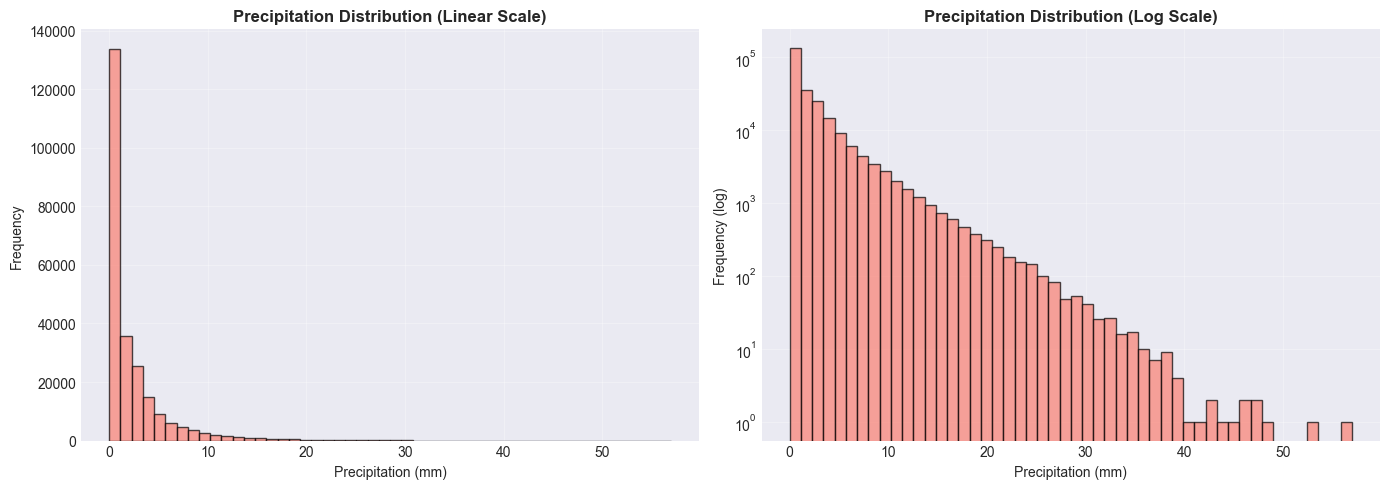

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
prec_clean = df_sample['precipitation'].dropna()
axes[0].hist(prec_clean, bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[0].set_title('Precipitation Distribution (Linear Scale)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].hist(prec_clean, bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_title('Precipitation Distribution (Log Scale)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Precipitation (mm)')
axes[1].set_ylabel('Frequency (log)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Phân tích Precipitation với bộ lọc (99th percentile)

Loại bỏ các outlier cực đoan để nhìn rõ hơn phân phối chính

C:\Users\Hello\AppData\Local\Temp\ipykernel_23312\1691640250.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_sample['precipitation'].dropna()], labels=['Precipitation'])


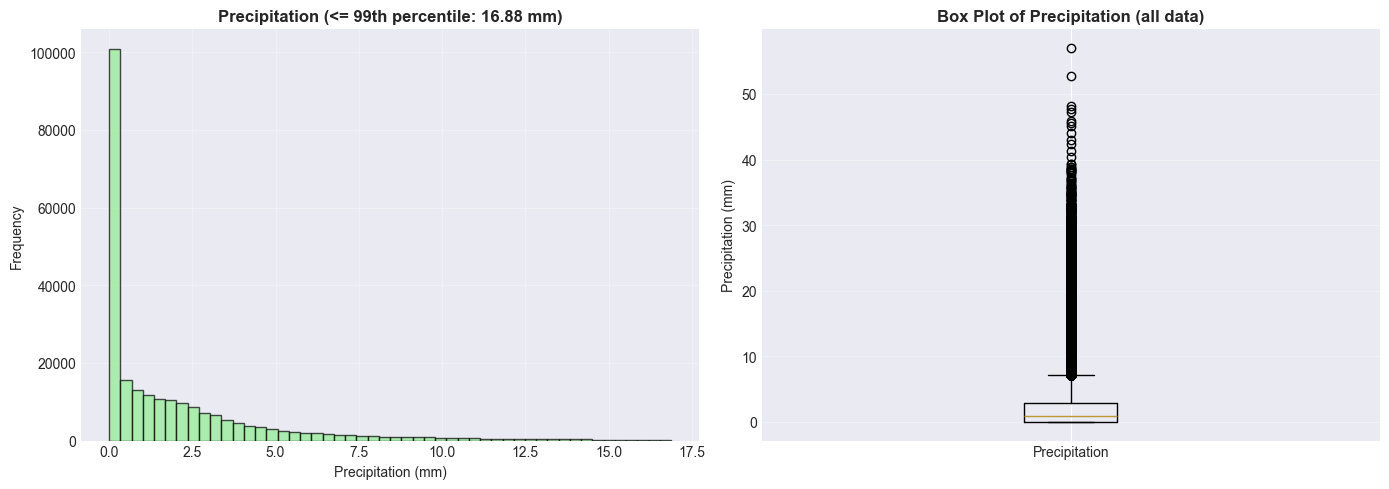

In [26]:
# Filter precipitation at 99th percentile
upper_quantile = np.nanquantile(df_sample['precipitation'], 0.99)
filtered_prec = df_sample['precipitation'][df_sample['precipitation'] <= upper_quantile].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filtered
axes[0].hist(filtered_prec, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Precipitation (<= 99th percentile: {upper_quantile:.2f} mm)',
                   fontweight='bold', fontsize=12)
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot([df_sample['precipitation'].dropna()], labels=['Precipitation'])
axes[1].set_title('Box Plot of Precipitation (all data)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Precipitation (mm)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Biểu đồ tương quan (Correlation Analysis)

Phân tích mối quan hệ giữa các biến số

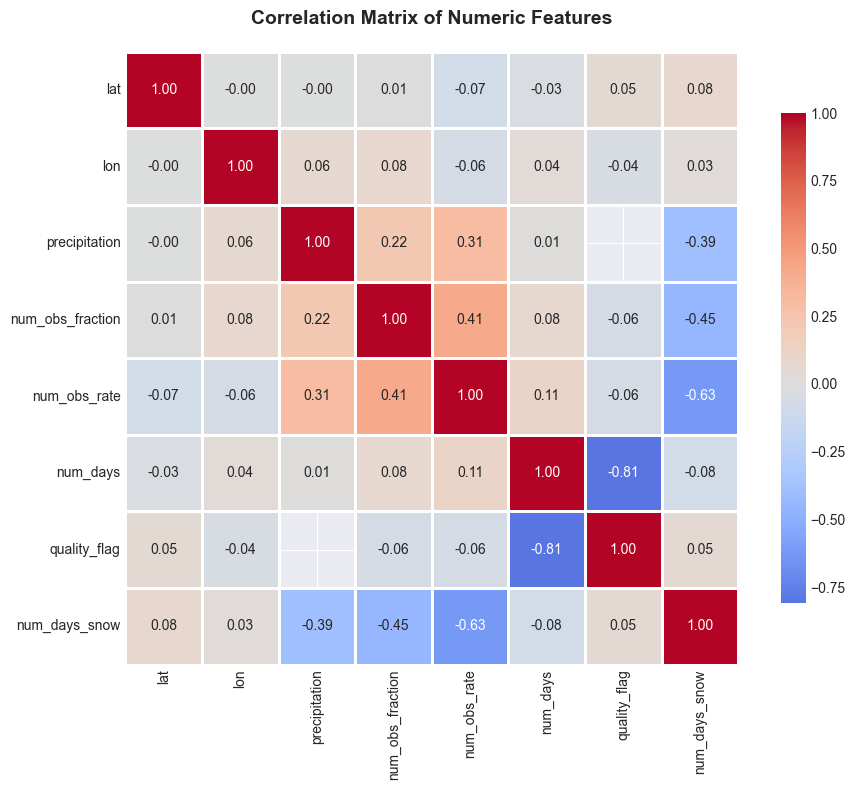

In [27]:
# Correlation matrix
correlation = df_sample[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix of Numeric Features', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 6. Bản đồ tương tác (Interactive World Map)

Biểu diễn dữ liệu lượng mưa trên bản đồ thế giới. Bạn có thể:
- **Lăn chuột**: Thu phóng vào/ra
- **Nhấn giữ + kéo**: Di chuyển bản đồ
- **Xem Heatmap**: Hiển thị mật độ mưa

In [28]:
# Create interactive map with folium
from IPython.display import display, HTML

# Filter data for map (remove NaN values)
map_data = df_sample[['lat', 'lon', 'precipitation']].dropna()

# Convert float32 to float to avoid JSON serialization error
map_data = map_data.astype('float64')

# Create base map centered on world (with max_bounds to prevent infinite repetition)
m = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles='OpenStreetMap',
    max_bounds=True
)

# Prepare data for heatmap (convert to native Python floats)
heat_data = [[float(row['lat']), float(row['lon']), float(row['precipitation'])] 
             for idx, row in map_data.iterrows()]

# Add heatmap layer
HeatMap(heat_data, 
        radius=15,
        blur=25,
        max_zoom=1,
        min_opacity=0.3,
        gradient={0.2: 'blue', 0.4: 'cyan', 0.6: 'lime', 0.8: 'yellow', 1.0: 'red'}
).add_to(m)

# Add marker cluster for individual points
marker_cluster = MarkerCluster(name='Data Points').add_to(m)

# Add a sample of points as markers (to avoid too many markers)
sample_map = map_data.sample(n=min(500, len(map_data)))
for idx, row in sample_map.iterrows():
    folium.CircleMarker(
        location=[float(row['lat']), float(row['lon'])],
        radius=3,
        popup=f"Precipitation: {float(row['precipitation']):.2f} mm",
        color='blue',
        fill=True,
        fillColor='blue',
        fillOpacity=0.3,
        weight=1
    ).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Display interactive map in notebook
display(m)

## 7. Tóm tắt phân tích (Summary Statistics)

In [29]:
# Summary statistics
print("="*70)
print("TÓM TẮT PHÂN TÍCH DỮ LIỆU".center(70))
print("="*70)

print("\nTHÔNG TIN CƠ BẢN:")
print(f"  • Tổng số hàng: {row_count:,}")
print(f"  • Tổng số cột: {col_count}")
print(f"  • Dữ liệu mẫu: {len(df_sample):,} hàng (1% của dữ liệu)")

print("\nVỊ TRÍ ĐỊA LÝ (Latitude & Longitude):")
print(f"  • Lat range: [{df_sample['lat'].min():.2f}, {df_sample['lat'].max():.2f}]")
print(f"  • Lon range: [{df_sample['lon'].min():.2f}, {df_sample['lon'].max():.2f}]")

print("\nLƯỢNG MƯA (Precipitation):")
prec_data = df_sample['precipitation'].dropna()
print(f"  • Valid values: {len(prec_data):,} ({len(prec_data)/len(df_sample)*100:.2f}%)")
print(f"  • Missing values: {df_sample['precipitation'].isna().sum():,} ({df_sample['precipitation'].isna().sum()/len(df_sample)*100:.2f}%)")
print(f"  • Min: {prec_data.min():.2f} mm")
print(f"  • Max: {prec_data.max():.2f} mm")
print(f"  • Mean: {prec_data.mean():.2f} mm")
print(f"  • Median: {prec_data.median():.2f} mm")
print(f"  • Std Dev: {prec_data.std():.2f} mm")

print("\nOUTLIERS (IQR Method):")
q1 = prec_data.quantile(0.25)
q3 = prec_data.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_outliers = (prec_data > upper).sum()
print(f"  • Upper bound: {upper:.2f} mm")
print(f"  • Outlier count: {n_outliers:,} ({n_outliers/len(prec_data)*100:.4f}%)")

print("\n" + "="*70)

                      TÓM TẮT PHÂN TÍCH DỮ LIỆU                       

THÔNG TIN CƠ BẢN:
  • Tổng số hàng: 24,883,200
  • Tổng số cột: 14
  • Dữ liệu mẫu: 248,832 hàng (1% của dữ liệu)

VỊ TRÍ ĐỊA LÝ (Latitude & Longitude):
  • Lat range: [-89.50, 89.50]
  • Lon range: [-179.50, 179.50]

LƯỢNG MƯA (Precipitation):
  • Valid values: 245,005 (98.46%)
  • Missing values: 3,827 (1.54%)
  • Min: 0.00 mm
  • Max: 56.99 mm
  • Mean: 2.18 mm
  • Median: 0.83 mm
  • Std Dev: 3.50 mm

OUTLIERS (IQR Method):
  • Upper bound: 7.11 mm
  • Outlier count: 18,936 (7.7288%)

